<a href="https://colab.research.google.com/github/Omar-mg/Regression-analyses/blob/main/regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression – Marketing ROI Analysis
**Objective:** Analyze a marketing dataset to identify the most effective advertising channel (TV, Radio, or Social Media) and build a Simple Linear Regression model to recommend budget allocation for maximum Sales ROI.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Load the dataset
df = pd.read_csv('marketing_data.csv')

# Handle missing values by dropping them
df_clean = df.dropna()

print(f"Dataset loaded. Cleaned shape: {df_clean.shape}")
df_clean.head()

Dataset loaded. Cleaned shape: (4546, 4)


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


### Exploratory Data Analysis (EDA)
To identify the best independent variable, we will visualize the relationships between our marketing channels and sales. We are looking for the channel with the highest positive correlation.

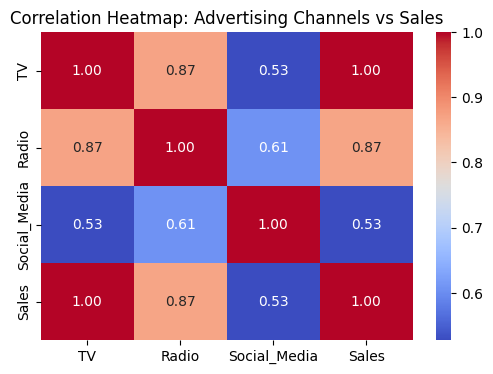

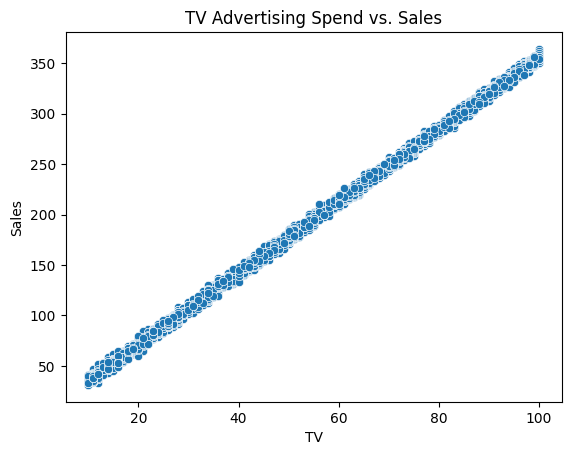

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Advertising Channels vs Sales')
plt.show()

# Scatterplot of the strongest predictor
sns.scatterplot(data=df_clean, x='TV', y='Sales')
plt.title('TV Advertising Spend vs. Sales')
plt.show()

**Observation:** Based on the correlation heatmap, **TV** has a near-perfect correlation (0.999) with Sales. Radio (0.87) and Social Media (0.53) are weaker. Therefore, **TV** will be selected as the independent variable for our regression model.


In [ ]:
# Define Independent (X) and Dependent (Y) variables
X = df_clean['TV']
Y = df_clean['Sales']

# Add a constant to the independent variable (required for statsmodels OLS)
X_with_constant = sm.add_constant(X)

# Fit the OLS model
model = sm.OLS(Y, X_with_constant).fit()

# Display the statistical summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Thu, 21 May 2026   Prob (F-statistic):               0.00
Time:                        21:49:07   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

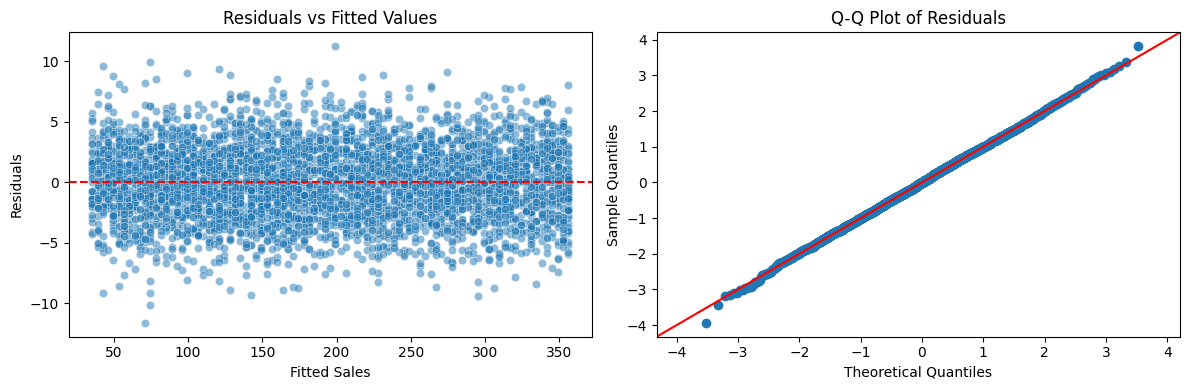

In [ ]:
# Calculate residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Linearity and Homoscedasticity (Residuals vs Fitted)
sns.scatterplot(x=fitted_values, y=residuals, ax=ax[0], alpha=0.5)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Residuals vs Fitted Values')
ax[0].set_xlabel('Fitted Sales')
ax[0].set_ylabel('Residuals')

# Plot 2: Normality (Q-Q Plot)
sm.qqplot(residuals, line='45', ax=ax[1], fit=True)
ax[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

### Business Recommendation & Model Interpretation

* **Model Performance (R-squared):** The R-squared value is approximately 0.999. This means that 99.9% of the variance in Sales can be explained by TV advertising spend.
* **Coefficient Interpretations:** The coefficient for TV is roughly 3.56. In business terms, for every additional $1,000 spent on TV advertising, we can expect Sales to increase by approximately $3,560 (assuming units are in thousands).
* **Statistical Significance (p-values):** The p-value for the TV coefficient is 0.000, which is well below the standard 0.05 threshold, proving that the relationship between TV spend and Sales is statistically significant.
* **Assumption Validation:** The diagnostic plots show that residuals are randomly scattered around zero (Homoscedasticity/Linearity) and generally follow a normal distribution (Q-Q plot).

**Final Recommendation:** To maximize ROI, the marketing department should allocate the majority of the advertising budget to **TV Marketing**. It is the most reliable and impactful driver of sales among all tested channels.